#📌 Extracción

In [68]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [69]:
import pandas as pd
import json
import matplotlib.pyplot as plt

## 1. Carga de datos (JSON)

In [70]:
# 2. Leer el archivo como JSON primero
ruta = '/content/drive/MyDrive/alura/TelecomX_Data.json'
with open(ruta, 'r') as f:
    datos = json.load(f)

## Primera visualización  

In [71]:
df1= pd.DataFrame(datos)
df1

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


## 2. Normalización del JSON

In [72]:
df = pd.json_normalize(datos, sep='_')
df

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


## 3. Renombrar columnas

In [73]:
nuevos_nombres = {
    'customerID': 'id',
    'Churn': 'abandono',
    'customer_gender': 'genero',
    'customer_SeniorCitizen': 'adulto_mayor',
    'customer_Partner': 'socio',
    'customer_Dependents': 'dependientes',
    'customer_tenure': 'meses_antiguedad',
    'phone_PhoneService': 'servicio_telefono',
    'phone_MultipleLines': 'lineas_multiples',
    'internet_InternetService': 'tipo_internet',
    'internet_OnlineSecurity': 'seguridad_online',
    'internet_OnlineBackup': 'respaldo_online',
    'internet_DeviceProtection': 'proteccion_dispositivo',
    'internet_TechSupport': 'soporte_tecnico',
    'internet_StreamingTV': 'streaming_tv',
    'internet_StreamingMovies': 'streaming_peliculas',
    'account_Contract': 'tipo_contrato',
    'account_PaperlessBilling': 'factura_digital',
    'account_PaymentMethod': 'metodo_pago',
    'account_Charges_Monthly': 'cargo_mensual',
    'account_Charges_Total': 'cargo_total'
}

In [74]:
df.rename(columns= nuevos_nombres, inplace=True)

##4. Explorar las columnas del dataset y verificar sus tipos de datos.

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      7267 non-null   object 
 1   abandono                7267 non-null   object 
 2   genero                  7267 non-null   object 
 3   adulto_mayor            7267 non-null   int64  
 4   socio                   7267 non-null   object 
 5   dependientes            7267 non-null   object 
 6   meses_antiguedad        7267 non-null   int64  
 7   servicio_telefono       7267 non-null   object 
 8   lineas_multiples        7267 non-null   object 
 9   tipo_internet           7267 non-null   object 
 10  seguridad_online        7267 non-null   object 
 11  respaldo_online         7267 non-null   object 
 12  proteccion_dispositivo  7267 non-null   object 
 13  soporte_tecnico         7267 non-null   object 
 14  streaming_tv            7267 non-null   

In [76]:
df.dtypes

,0
id,object
abandono,object
genero,object
adulto_mayor,int64
socio,object
dependientes,object
meses_antiguedad,int64
servicio_telefono,object
lineas_multiples,object
tipo_internet,object


**¿Cuántas columnas hay?**

21

**¿Cuántos registros?**

7267

**¿Qué tipo de dato tiene cada variable?**  

float64(1), int64(2), object(18)

**¿Hay valores nulos?**

No

##Entender el significado de las variables (diccionario de datos)

1. Información del cliente (perfil)
* genero
* adulto_mayor
* socio
* dependientes

2. Antigüedad y relación con la empresa
* meses_antiguedad

3. Servicios contratados
servicio_telefono

* lineas_multiples

* tipo_internet

* seguridad_online

* respaldo_online

* proteccion_dispositivo

* soporte_tecnico

* streaming_tv

* streaming_peliculas

4. Condiciones contractuales y de pago
* tipo_contrato

* factura_digital

* metodo_pago

5. Variables económicas
* cargo_mensual
* cargo_total

6. Variable objetivo
* abandono

El dataset contiene 7.267 registros de clientes y 21 variables, incluyendo información demográfica, servicios contratados, condiciones de pago y cargos financieros. No se identifican valores nulos según la inspección inicial con info(). La variable objetivo es abandono, que indica la evasión del cliente. Se observa que la mayoría de las variables son categóricas, mientras que las variables numéricas principales corresponden a la antigüedad del cliente y a los cargos mensuales. La variable cargo_total se encuentra almacenada como tipo object, lo que sugiere la necesidad de una transformación posterior.

##Detectar problemas potenciales y dejarlos documentados.

¿Hay algo en los datos que pueda distorsionar el análisis de evasión si no lo detectamos a tiempo?

**NULOS**

In [77]:
df.isnull().sum()

,0
id,0
abandono,0
genero,0
adulto_mayor,0
socio,0
dependientes,0
meses_antiguedad,0
servicio_telefono,0
lineas_multiples,0
tipo_internet,0


**No se identificaron valores nulos (NaN) en el dataset.**

**DUPLICADOS**

¿Hay clientes repetidos?

In [78]:
df.duplicated().sum()

np.int64(0)

¿Hay filas idénticas?

In [79]:
df['id'].duplicated().sum()

np.int64(0)

In [80]:
df['cargo_total'].isna().sum()

np.int64(0)

**Errores de formato**

cargo_total → object

In [81]:
df['cargo_total'].unique()

array(['593.3', '542.4', '280.85', ..., '742.9', '4627.65', '3707.6'],
      dtype=object)

La variable cargo_total presenta un formato incorrecto para análisis numérico, por lo que requerirá transformación en etapas posteriores.

**Inconsistencias en categorías**

In [82]:
columnas_categoricas= ['genero',
'adulto_mayor',
'socio',
'dependientes',
'meses_antiguedad',
'servicio_telefono',
'lineas_multiples',
'tipo_internet',
'seguridad_online',
'respaldo_online',
'proteccion_dispositivo',
'soporte_tecnico',
'streaming_tv',
'streaming_peliculas',
'tipo_contrato',
'factura_digital',
'metodo_pago',
'cargo_mensual',
'cargo_total',
'abandono']

In [83]:
for col in columnas_categoricas:
  print(f'valores unicos en {col}:')
  print(df[col].unique())
  print('-'*40)

valores unicos en genero:
['Female' 'Male']
----------------------------------------
valores unicos en adulto_mayor:
[0 1]
----------------------------------------
valores unicos en socio:
['Yes' 'No']
----------------------------------------
valores unicos en dependientes:
['Yes' 'No']
----------------------------------------
valores unicos en meses_antiguedad:
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
----------------------------------------
valores unicos en servicio_telefono:
['Yes' 'No']
----------------------------------------
valores unicos en lineas_multiples:
['No' 'Yes' 'No phone service']
----------------------------------------
valores unicos en tipo_internet:
['DSL' 'Fiber optic' 'No']
----------------------------------------
valores unicos en seguridad_online:
['No' 'Yes' 'No internet service'

La exploración de valores únicos en las variables categóricas muestra que la mayoría de las columnas presentan categorías coherentes y bien definidas. Sin embargo, se identificaron inconsistencias relevantes en la variable objetivo abandono, la cual contiene valores vacíos además de las categorías esperadas (“Yes” y “No”). Asimismo, se confirma que la variable cargo_total se encuentra almacenada como texto, lo que requerirá una transformación antes de su uso en análisis numérico. Estas observaciones indican la necesidad de una etapa de limpieza de datos previa al análisis exploratorio.

In [84]:
df[
    (df['tipo_internet'] == 'No') &
    (
        (df['streaming_tv'] == 'Yes') |
        (df['streaming_peliculas'] == 'Yes') |
        (df['seguridad_online'] == 'Yes') |
        (df['respaldo_online'] == 'Yes') |
        (df['soporte_tecnico'] == 'Yes')
    )
]

,id,abandono,genero,adulto_mayor,socio,dependientes,meses_antiguedad,servicio_telefono,lineas_multiples,tipo_internet,...,respaldo_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,cargo_mensual,cargo_total


In [85]:
df[
    (df['servicio_telefono'] == 'No') &
    (df['lineas_multiples'] == 'Yes')
]

,id,abandono,genero,adulto_mayor,socio,dependientes,meses_antiguedad,servicio_telefono,lineas_multiples,tipo_internet,...,respaldo_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,cargo_mensual,cargo_total


In [86]:
df[
    (df['meses_antiguedad'] == 0) &
    (df['cargo_mensual'] > 0)
]

,id,abandono,genero,adulto_mayor,socio,dependientes,meses_antiguedad,servicio_telefono,lineas_multiples,tipo_internet,...,respaldo_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,cargo_mensual,cargo_total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,


Se realizaron validaciones de coherencia lógica entre variables relacionadas con servicios. No se identificaron inconsistencias relevantes entre el tipo de servicio contratado y los servicios adicionales asociados. Asimismo, se revisaron posibles incoherencias entre la antigüedad del cliente y los cargos reportados, las cuales serán consideradas en etapas posteriores del análisis.

Se identificaron clientes con antigüedad igual a 0 meses y cargos mensuales mayores a cero. Este comportamiento es consistente con clientes recientemente incorporados al servicio, que aún no acumulan cargos totales, por lo que no se considera una inconsistencia en los datos.

#🔧 Transformación

In [87]:
cols_object =  df.select_dtypes(include='object').columns
df[cols_object] = df[cols_object].apply(lambda x: x.str.lower())

**Corrección 1: valores vacíos en abandono**

In [88]:
(df['abandono'] == '').sum()

np.int64(224)

In [89]:
df['abandono'] = df['abandono'].replace('', pd.NA)

In [90]:
(df['abandono'] == '').sum()

np.int64(0)

**Corrección 2: cargo_total a numérico**

In [91]:
df['cargo_total'] = pd.to_numeric(df['cargo_total'], errors='coerce')

In [92]:
df['cargo_total'].dtype

dtype('float64')

**Corrección 3: clientes nuevos (meses_antiguedad = 0) con (cargo_total = (vacio))**

In [93]:
df['cargo_total'].isna().sum()

np.int64(11)

In [94]:
df.loc[(df['meses_antiguedad'] == 0) & (df['cargo_total'].isna()) , 'cargo_total'] = 0

In [95]:
df['cargo_total'].isna().sum()

np.int64(0)

In [96]:
df.head()

,id,abandono,genero,adulto_mayor,socio,dependientes,meses_antiguedad,servicio_telefono,lineas_multiples,tipo_internet,...,respaldo_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,cargo_mensual,cargo_total
0,0002-orfbo,no,female,0,yes,yes,9,yes,no,dsl,...,yes,no,yes,yes,no,one year,yes,mailed check,65.6,593.30
1,0003-mknfe,no,male,0,no,no,9,yes,yes,dsl,...,no,no,no,no,yes,month-to-month,no,mailed check,59.9,542.40
2,0004-tlhlj,yes,male,0,no,no,4,yes,no,fiber optic,...,no,yes,no,no,no,month-to-month,yes,electronic check,73.9,280.85
3,0011-igkff,yes,male,1,yes,no,13,yes,no,fiber optic,...,yes,yes,no,yes,yes,month-to-month,yes,electronic check,98.0,1237.85
4,0013-exchz,yes,female,1,yes,no,3,yes,no,fiber optic,...,no,no,yes,yes,no,month-to-month,yes,mailed check,83.9,267.40


**7 Estandarización de servicios de internet (CLAVE)**

In [97]:
df['lineas_multiples'].unique()

array(['no', 'yes', 'no phone service'], dtype=object)

In [98]:
# valores unicos en seguridad_online:
# ['No' 'Yes' 'No internet service']
# ----------------------------------------
# valores unicos en respaldo_online:
# ['Yes' 'No' 'No internet service']
# ----------------------------------------
# valores unicos en proteccion_dispositivo:
# ['No' 'Yes' 'No internet service']
# ----------------------------------------
# valores unicos en soporte_tecnico:
# ['Yes' 'No' 'No internet service']
# ----------------------------------------
# valores unicos en streaming_tv:
# ['Yes' 'No' 'No internet service']
# ----------------------------------------
# valores unicos en streaming_peliculas:
# ['No' 'Yes' 'No internet service']

internet_cols = ['seguridad_online', 'respaldo_online','proteccion_dispositivo',
                 'soporte_tecnico','streaming_tv','streaming_peliculas']

for col in internet_cols:
  df[col] = df[col].replace('no internet service','no')

for col in internet_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})


In [99]:
df['streaming_tv'].unique()

array([1, 0])

In [100]:
df['lineas_multiples'] = df['lineas_multiples'].map(
    lambda x: 1 if x == 'yes' else 0
)

In [101]:
df['lineas_multiples'].unique()

array([0, 1])

**VERFICAFCION FINAL**

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      7267 non-null   object 
 1   abandono                7043 non-null   object 
 2   genero                  7267 non-null   object 
 3   adulto_mayor            7267 non-null   int64  
 4   socio                   7267 non-null   object 
 5   dependientes            7267 non-null   object 
 6   meses_antiguedad        7267 non-null   int64  
 7   servicio_telefono       7267 non-null   object 
 8   lineas_multiples        7267 non-null   int64  
 9   tipo_internet           7267 non-null   object 
 10  seguridad_online        7267 non-null   int64  
 11  respaldo_online         7267 non-null   int64  
 12  proteccion_dispositivo  7267 non-null   int64  
 13  soporte_tecnico         7267 non-null   int64  
 14  streaming_tv            7267 non-null   

In [103]:
df.isnull().sum()

,0
id,0
abandono,224
genero,0
adulto_mayor,0
socio,0
dependientes,0
meses_antiguedad,0
servicio_telefono,0
lineas_multiples,0
tipo_internet,0


In [104]:
df = df.dropna(subset=['abandono'])

In [105]:
df =df.copy()

In [106]:
df

,id,abandono,genero,adulto_mayor,socio,dependientes,meses_antiguedad,servicio_telefono,lineas_multiples,tipo_internet,...,respaldo_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,cargo_mensual,cargo_total
0,0002-orfbo,no,female,0,yes,yes,9,yes,0,dsl,...,1,0,1,1,0,one year,yes,mailed check,65.60,593.30
1,0003-mknfe,no,male,0,no,no,9,yes,1,dsl,...,0,0,0,0,1,month-to-month,no,mailed check,59.90,542.40
2,0004-tlhlj,yes,male,0,no,no,4,yes,0,fiber optic,...,0,1,0,0,0,month-to-month,yes,electronic check,73.90,280.85
3,0011-igkff,yes,male,1,yes,no,13,yes,0,fiber optic,...,1,1,0,1,1,month-to-month,yes,electronic check,98.00,1237.85
4,0013-exchz,yes,female,1,yes,no,3,yes,0,fiber optic,...,0,0,1,1,0,month-to-month,yes,mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-lutyd,no,female,0,no,no,13,yes,0,dsl,...,0,0,1,0,0,one year,no,mailed check,55.15,742.90
7263,9992-rramn,yes,male,0,yes,no,22,yes,1,fiber optic,...,0,0,0,0,1,month-to-month,yes,electronic check,85.10,1873.70
7264,9992-ujoel,no,male,0,no,no,2,yes,0,dsl,...,1,0,0,0,0,month-to-month,yes,mailed check,50.30,92.75
7265,9993-lhieb,no,male,0,yes,yes,67,yes,0,dsl,...,0,1,1,0,1,two year,no,mailed check,67.85,4627.65


Se identificaron 224 registros con valores faltantes en la variable objetivo abandono. Dado que esta variable es fundamental para el análisis de evasión, dichos registros fueron excluidos del dataset.

**CREACION DE COLUMNA CUENTAS DIARIAS**

In [107]:
df['cuenta_diarias'] = (df['cargo_mensual']/30).round(2)

In [108]:
df[['cargo_mensual','cuenta_diarias']].head()

,cargo_mensual,cuenta_diarias
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80


In [109]:
df

,id,abandono,genero,adulto_mayor,socio,dependientes,meses_antiguedad,servicio_telefono,lineas_multiples,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,cargo_mensual,cargo_total,cuenta_diarias
0,0002-orfbo,no,female,0,yes,yes,9,yes,0,dsl,...,0,1,1,0,one year,yes,mailed check,65.60,593.30,2.19
1,0003-mknfe,no,male,0,no,no,9,yes,1,dsl,...,0,0,0,1,month-to-month,no,mailed check,59.90,542.40,2.00
2,0004-tlhlj,yes,male,0,no,no,4,yes,0,fiber optic,...,1,0,0,0,month-to-month,yes,electronic check,73.90,280.85,2.46
3,0011-igkff,yes,male,1,yes,no,13,yes,0,fiber optic,...,1,0,1,1,month-to-month,yes,electronic check,98.00,1237.85,3.27
4,0013-exchz,yes,female,1,yes,no,3,yes,0,fiber optic,...,0,1,1,0,month-to-month,yes,mailed check,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-lutyd,no,female,0,no,no,13,yes,0,dsl,...,0,1,0,0,one year,no,mailed check,55.15,742.90,1.84
7263,9992-rramn,yes,male,0,yes,no,22,yes,1,fiber optic,...,0,0,0,1,month-to-month,yes,electronic check,85.10,1873.70,2.84
7264,9992-ujoel,no,male,0,no,no,2,yes,0,dsl,...,0,0,0,0,month-to-month,yes,mailed check,50.30,92.75,1.68
7265,9993-lhieb,no,male,0,yes,yes,67,yes,0,dsl,...,1,1,0,1,two year,no,mailed check,67.85,4627.65,2.26


**estandarizar columnas a binario (0 / 1)**

In [110]:
estandarizacion_col = ['socio',
'dependientes',
'servicio_telefono',
'factura_digital',
'abandono']

for col in estandarizacion_col:
  df[col] = df[col].replace('no internet service','no')

for col in estandarizacion_col:
    df[col] = df[col].map({'yes': 1, 'no': 0})

In [111]:
for col in columnas_categoricas:
  print(f'valores unicos en {col}:')
  print(df[col].unique())
  print('-'*40)

valores unicos en genero:
['female' 'male']
----------------------------------------
valores unicos en adulto_mayor:
[0 1]
----------------------------------------
valores unicos en socio:
[1 0]
----------------------------------------
valores unicos en dependientes:
[1 0]
----------------------------------------
valores unicos en meses_antiguedad:
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42
  0]
----------------------------------------
valores unicos en servicio_telefono:
[1 0]
----------------------------------------
valores unicos en lineas_multiples:
[0 1]
----------------------------------------
valores unicos en tipo_internet:
['dsl' 'fiber optic' 'no']
----------------------------------------
valores unicos en seguridad_online:
[0 1]
----------------------------------------
valores unicos en respaldo_online

#📊 Carga y análisis

In [112]:
df.head()

,id,abandono,genero,adulto_mayor,socio,dependientes,meses_antiguedad,servicio_telefono,lineas_multiples,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,cargo_mensual,cargo_total,cuenta_diarias
0,0002-orfbo,0,female,0,1,1,9,1,0,dsl,...,0,1,1,0,one year,1,mailed check,65.6,593.30,2.19
1,0003-mknfe,0,male,0,0,0,9,1,1,dsl,...,0,0,0,1,month-to-month,0,mailed check,59.9,542.40,2.00
2,0004-tlhlj,1,male,0,0,0,4,1,0,fiber optic,...,1,0,0,0,month-to-month,1,electronic check,73.9,280.85,2.46
3,0011-igkff,1,male,1,1,0,13,1,0,fiber optic,...,1,0,1,1,month-to-month,1,electronic check,98.0,1237.85,3.27
4,0013-exchz,1,female,1,1,0,3,1,0,fiber optic,...,0,1,1,0,month-to-month,1,mailed check,83.9,267.40,2.80


In [113]:
df.describe()

,abandono,adulto_mayor,socio,dependientes,meses_antiguedad,servicio_telefono,lineas_multiples,seguridad_online,respaldo_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,factura_digital,cargo_mensual,cargo_total,cuenta_diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.592219,64.761692,2279.734304,2.158675
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,30.090047,2266.794470,1.003088
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,398.550000,1.180000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1394.550000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,3786.600000,2.990000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


El análisis descriptivo muestra que aproximadamente el 26.5% de los clientes han abandonado el servicio. La antigüedad promedio es de 32 meses, con una distribución heterogénea en los cargos mensuales y totales. Menos de la mitad de los clientes contrata servicios adicionales de internet, lo que sugiere oportunidades de análisis para identificar factores asociados a la evasión.

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      7043 non-null   object 
 1   abandono                7043 non-null   int64  
 2   genero                  7043 non-null   object 
 3   adulto_mayor            7043 non-null   int64  
 4   socio                   7043 non-null   int64  
 5   dependientes            7043 non-null   int64  
 6   meses_antiguedad        7043 non-null   int64  
 7   servicio_telefono       7043 non-null   int64  
 8   lineas_multiples        7043 non-null   int64  
 9   tipo_internet           7043 non-null   object 
 10  seguridad_online        7043 non-null   int64  
 11  respaldo_online         7043 non-null   int64  
 12  proteccion_dispositivo  7043 non-null   int64  
 13  soporte_tecnico         7043 non-null   int64  
 14  streaming_tv            7043 non-null   int64

analisis abandono:     'meses_antiguedad',
    'cargo_mensual',
    'cargo_total',
    'cuenta_diarias'

In [115]:
cols_interes = [
    'meses_antiguedad',
    'cargo_mensual',
    'cargo_total',
    'cuenta_diarias'
]

desc = df.groupby('abandono')[cols_interes].describe()


In [116]:
desc_largo = desc.stack(level=0)
desc_largo

/tmp/ipykernel_280/1096820398.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  desc_largo = desc.stack(level=0)


count         mean          std    min     25%  \
abandono                                                                     
0        cargo_mensual     5174.0    61.265124    31.092648  18.25   25.10   
         cargo_total       5174.0  2549.911442  2329.954215   0.00  572.90   
         cuenta_diarias    5174.0     2.042080     1.036492   0.61    0.84   
         meses_antiguedad  5174.0    37.569965    24.113777   0.00   15.00   
1        cargo_mensual     1869.0    74.441332    24.666053  18.85   56.15   
         cargo_total       1869.0  1531.796094  1890.822994  18.85  134.50   
         cuenta_diarias    1869.0     2.481450     0.822287   0.63    1.87   
         meses_antiguedad  1869.0    17.979133    19.531123   1.00    2.00   

                                50%      75%      max  
abandono                                               
0        cargo_mensual       64.425    88.40   118.75  
         cargo_total       1679.525  4262.85  8672.45  
         cuenta_diarias       2.150     2.95     3.96  
         meses_antiguedad    38.000    61.00    72.00  
1        cargo_mensual       79.650    94.20   118.35  
         cargo_total        703.550  2331.30  8684.80  
         cuenta_diarias       2.660     3.14     3.94  
         meses_antiguedad    10.000    29.00    72.00

Los clientes que abandonan el servicio tienden a tener menor antigüedad, pagan cargos mensuales y diarios más altos, y generan un menor ingreso total acumulado. Esto sugiere que el abandono ocurre principalmente en etapas tempranas del ciclo de vida del cliente y podría estar relacionado con la percepción de altos costos del servicio.

**Otros analisis importantes con abandono**


In [117]:
def tabla_churn(col):
    tabla = pd.crosstab(df[col], df['abandono'])
    tabla = tabla.rename(index={0: 'no', 1: 'sí'}, columns={0: 'no', 1: 'sí'})
    return tabla.style.background_gradient(cmap='Reds')

In [118]:
tabla_churn('tipo_contrato')

abandono,no,sí
tipo_contrato,,
month-to-month,2220,1655
one year,1307,166
two year,1647,48


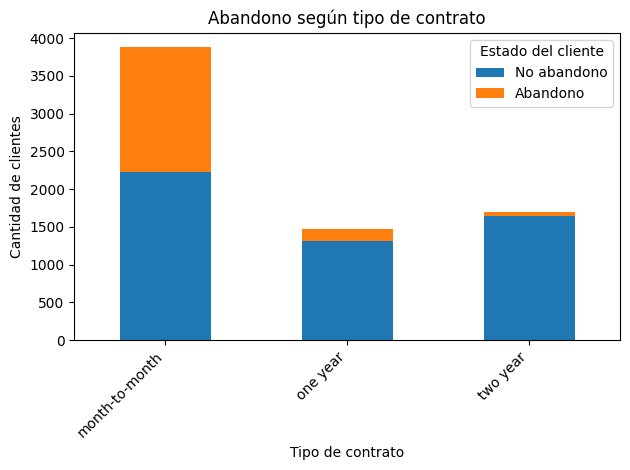

In [119]:
# tabla de contingencia
tabla = pd.crosstab(df['tipo_contrato'], df['abandono'])

# renombramos para que sea entendible
tabla.columns = ['No abandono', 'Abandono']

# gráfico
tabla.plot(kind='bar', stacked=True)

plt.title('Abandono según tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Cantidad de clientes')
plt.legend(title='Estado del cliente')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Contrato mensual = altísimo abandono

In [120]:
tabla_churn('tipo_internet')

abandono,no,sí
tipo_internet,,
dsl,1962,459
fiber optic,1799,1297
no,1413,113


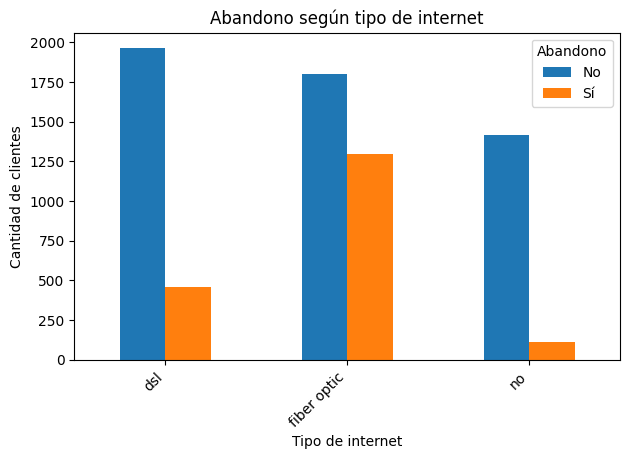

In [121]:
ct = pd.crosstab(df['tipo_internet'], df['abandono'])

# gráfico
ct.plot(kind='bar')

plt.title('Abandono según tipo de internet')
plt.xlabel('Tipo de internet')
plt.ylabel('Cantidad de clientes')
plt.legend(title='Abandono', labels=['No', 'Sí'])
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

Fiber optic → 1297 abandonos (muy alto)

**buen candidato para análisis cruzado con cargo_mensual**

In [122]:
tabla_churn('lineas_multiples')

abandono,no,sí
lineas_multiples,,
no,3053,1019
sí,2121,850


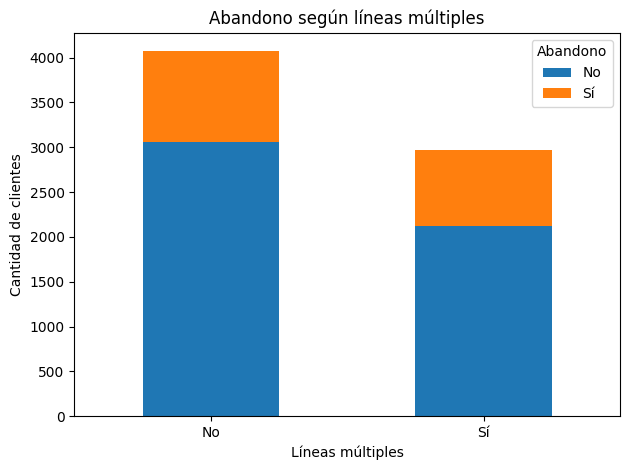

In [123]:
ct = pd.crosstab(df['lineas_multiples'], df['abandono'])

ct.plot(
    kind='bar',
    stacked=True
)

plt.title('Abandono según líneas múltiples')
plt.xlabel('Líneas múltiples')
plt.ylabel('Cantidad de clientes')
plt.legend(title='Abandono', labels=['No', 'Sí'])

plt.xticks(
    ticks=[0, 1],
    labels=['No', 'Sí'],
    rotation=0
)

plt.tight_layout()
plt.show()


Más servicios = más dificultad para abandonar

In [124]:
tabla_churn('dependientes')

abandono,no,sí
dependientes,,
no,3390,1543
sí,1784,326


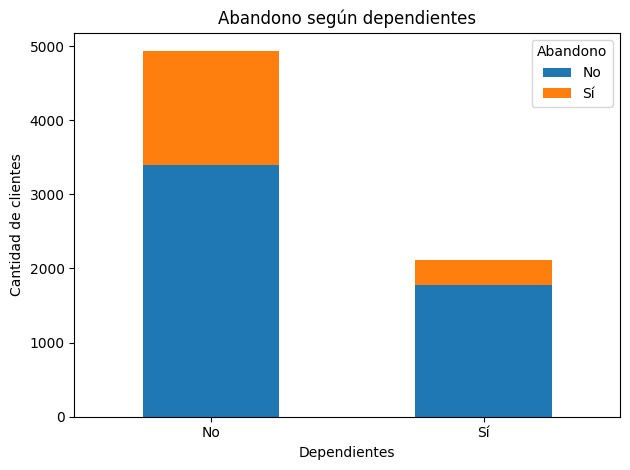

In [125]:
ct = pd.crosstab(df['dependientes'], df['abandono'])

ct.plot(
    kind='bar',
    stacked=True
)

plt.title('Abandono según dependientes')
plt.xlabel('Dependientes')
plt.ylabel('Cantidad de clientes')
plt.legend(title='Abandono', labels=['No', 'Sí'])

plt.xticks(
    ticks=[0, 1],
    labels=['No', 'Sí'],
    rotation=0
)

plt.tight_layout()
plt.show()


Clientes con familia tienden a ser más estables y no abandonar

In [126]:
tabla_churn('genero')

abandono,no,sí
genero,,
female,2549,939
male,2625,930


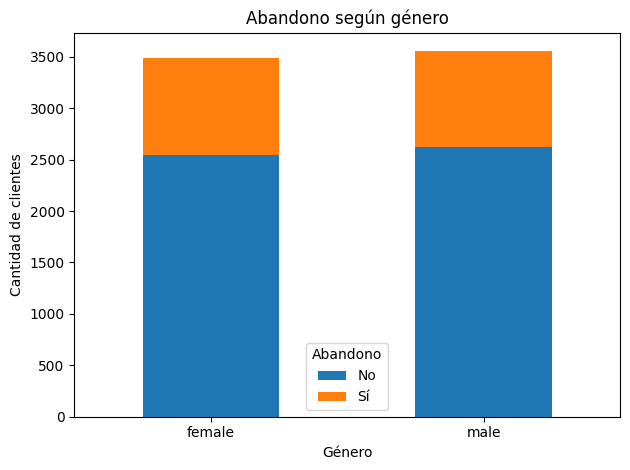

In [127]:
tabla_genero = pd.crosstab(df['genero'], df['abandono'])

# Gráfico
tabla_genero.plot(
    kind='bar',
    stacked=True
)

plt.title('Abandono según género')
plt.xlabel('Género')
plt.ylabel('Cantidad de clientes')
plt.legend(title='Abandono', labels=['No', 'Sí'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Género NO es un factor relevante

In [128]:
tabla_churn('metodo_pago')

abandono,no,sí
metodo_pago,,
bank transfer (automatic),1286,258
credit card (automatic),1290,232
electronic check,1294,1071
mailed check,1304,308


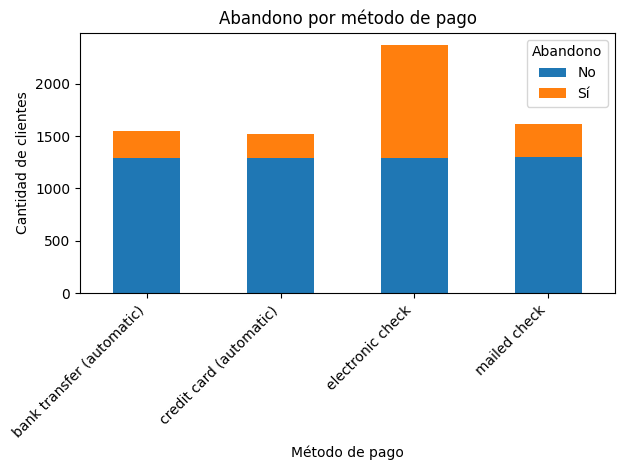

In [129]:
tabla = pd.crosstab(df['metodo_pago'], df['abandono'])

# Gráfico de barras apiladas
tabla.plot(kind='bar', stacked=True)

plt.title('Abandono por método de pago')
plt.xlabel('Método de pago')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Abandono', labels=['No', 'Sí'])

plt.tight_layout()
plt.show()

Electronic check es el método con mayor abandono

##**Graficos**

In [130]:
conteo_abandono = df['abandono'].value_counts().sort_index()

Text(0.5, 1.0, 'Distribución de usuarios que abandonaron la empresa')

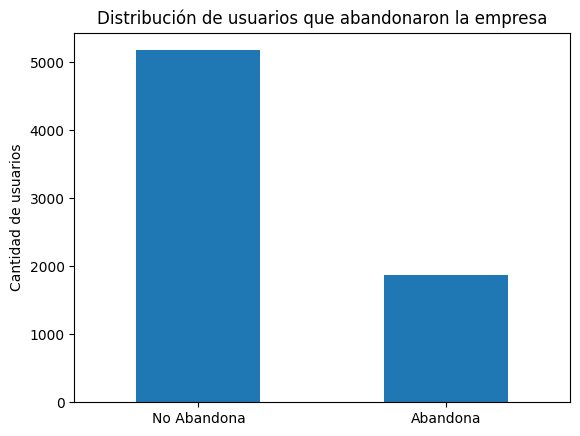

In [131]:
plt.figure()
conteo_abandono.plot(kind='bar')

plt.xticks([0,1],['No Abandona','Abandona'], rotation=0)
plt.xlabel('')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de usuarios que abandonaron la empresa')


(np.float64(-1.0999975336277057),
 np.float64(1.0999996372250127),
 np.float64(-1.099995395504405),
 np.float64(1.099999780738305))

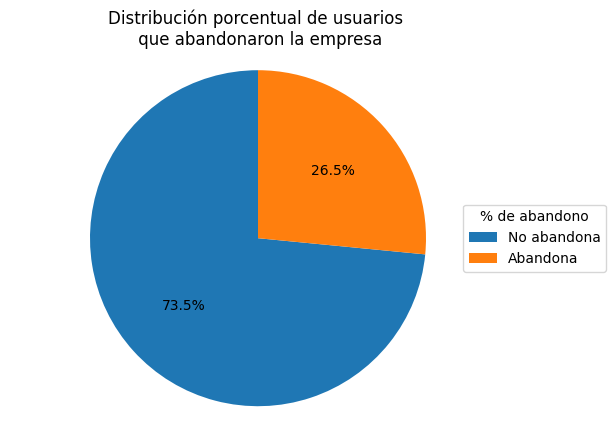

In [132]:
labels=['No abandona', 'Abandona']

plt.figure()
plt.pie(
    conteo_abandono,
    autopct= '%1.1f%%',
    startangle=90
)

plt.legend(
    labels,
    title='% de abandono',
    loc='center left',
    bbox_to_anchor=(0.9, 0.5)
)

plt.title('Distribución porcentual de usuarios \n que abandonaron la empresa')
plt.axis('equal')

#📄Informe final

##Introducción

El objetivo de este análisis es identificar los factores que influyen en la evasión de clientes (Churn) dentro de la empresa de telecomunicaciones.

El Churn ocurre cuando un cliente decide cancelar su servicio. Este fenómeno representa un problema importante para las empresas, ya que adquirir nuevos clientes suele ser más costoso que retener a los actuales.

A través de este análisis se busca:

Comprender el comportamiento de los clientes.

Identificar patrones asociados al abandono.

Detectar variables que influyen en la decisión de cancelar el servicio.

Generar insights estratégicos que permitan mejorar la retención de clientes.

Para ello se realizó un proceso completo de limpieza de datos, análisis exploratorio y visualización, con el fin de extraer conclusiones basadas en los datos.

##Limpieza y Tratamiento de Datos

Antes de realizar el análisis, fue necesario preparar el conjunto de datos mediante varios pasos de limpieza y transformación.

**1️) Importación de los datos**

Los datos fueron cargados en un DataFrame de Pandas, lo que permitió manipular y analizar la información de manera eficiente.

**2️) Revisión de la estructura del dataset**

Se verificaron:

Tipos de datos

Columnas disponibles

Cantidad de registros

Valores nulos

**3️) Tratamiento de valores faltantes**

Se identificaron posibles valores nulos o vacíos en algunas variables, los cuales fueron corregidos o eliminados según correspondía para evitar sesgos en el análisis.

**4️) Conversión de tipos de datos**

Algunas variables fueron transformadas a formatos adecuados para facilitar su análisis, por ejemplo:

Variables categóricas

Variables numéricas

Variables binarias (Sí / No)

**5️) Creación de variables útiles**

Se generaron variables derivadas que facilitaron el análisis del abandono de clientes, permitiendo realizar comparaciones entre distintos grupos.

Análisis Exploratorio de Datos (EDA)

**El Análisis Exploratorio de Datos permitió comprender mejor la distribución de los clientes y detectar patrones asociados al abandono.**

**Se realizaron diversos análisis y visualizaciones para explorar la relación entre el churn y diferentes variables.**

**Distribución de clientes que abandonan**

Se analizó la proporción de clientes que cancelaron el servicio frente a aquellos que permanecen.

Este análisis permitió observar que:

Existe una proporción significativa de clientes que abandonan el servicio.

La evasión representa un desafío relevante para la empresa.

**Abandono por género**

Se comparó la tasa de abandono entre hombres y mujeres.

Resultados principales:

No se observan diferencias significativas entre géneros.

El género no parece ser un factor determinante en la evasión.

**Abandono por método de pago**

Se analizaron los distintos métodos de pago utilizados por los clientes.

Hallazgos importantes:

Los clientes que utilizan Electronic Check presentan una mayor tasa de abandono.

Los clientes que utilizan pagos automáticos (tarjeta o transferencia bancaria) muestran mayor permanencia.

Esto sugiere que los métodos de pago automáticos pueden estar asociados a mayor fidelización.

**Abandono por tipo de contrato**

Se comparó el churn entre distintos tipos de contrato:

Contrato mensual

Contrato anual

Contrato de dos años

Principales resultados:

Los clientes con contrato mensual presentan la mayor tasa de abandono.

Los contratos a largo plazo (1 o 2 años) tienen tasas de evasión considerablemente menores.

Esto indica que la duración del contrato influye fuertemente en la retención.

##Conclusiones e Insights

**A partir del análisis exploratorio se identificaron varios factores relacionados con el abandono de clientes.**

**Principales hallazgos**

1️) El tipo de contrato es uno de los factores más influyentes.
Los clientes con contratos mensuales tienen mayor probabilidad de cancelar el servicio.

2️) El método de pago influye en la retención.
Los clientes que utilizan Electronic Check presentan mayor churn, mientras que los pagos automáticos muestran mayor estabilidad.

3️) El género no tiene un impacto significativo en el abandono.

4️) Los clientes con mayor compromiso contractual tienden a permanecer más tiempo.

Estos hallazgos pueden ayudar a la empresa a diseñar estrategias enfocadas en la retención de clientes.

##Recomendaciones

**Con base en los resultados del análisis, se proponen las siguientes estrategias para reducir la evasión de clientes.**

**1. Incentivar contratos a largo plazo**

Ofrecer beneficios para clientes que elijan contratos de 1 o 2 años, como:

Descuentos

Servicios adicionales

Mejores condiciones de precio

Esto puede aumentar la retención.

**2. Promover métodos de pago automáticos**

Fomentar el uso de:

Pago automático con tarjeta

Transferencia bancaria automática

Esto podría reducir la probabilidad de cancelación.

**3. Identificar clientes con alto riesgo de abandono**

Utilizar modelos de predicción de churn para detectar clientes con alta probabilidad de cancelar el servicio y aplicar estrategias de retención temprana.

**4. Mejorar la experiencia del cliente**

Invertir en:

Atención al cliente

Soporte técnico

Programas de fidelización

Una mejor experiencia puede aumentar la satisfacción y reducir el churn.

El análisis permitió identificar factores clave asociados al abandono de clientes, como el tipo de contrato y el método de pago.

Comprender estos patrones permite a la empresa tomar decisiones estratégicas basadas en datos, con el objetivo de reducir la evasión y mejorar la fidelización de clientes.